In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train shape: (39073, 15)
test shape: (9769, 14)


,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,37194,50,Private,Masters,14,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,35,United-States,<=50K
1,31094,28,Private,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K
2,33815,29,Private,HS-grad,9,Married-civ-spouse,Other-service,Wife,White,Female,0,1902,35,United-States,>50K
3,14501,32,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,23400,62,State-gov,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K


,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,7763,28,Private,Some-college,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States
1,23882,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States
2,30508,46,Self-emp-not-inc,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,23,United-States
3,28912,39,Private,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,35,United-States
4,19485,21,State-gov,Some-college,10,Never-married,Other-service,Own-child,White,Female,0,0,25,United-States


In [ ]:
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

print("\n[train info]")
train_df.info()

print("\n[test info]")
test_df.info()

train shape: (39073, 15)
test shape: (9769, 14)

[train info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              39073 non-null  int64 
 1   age             39073 non-null  int64 
 2   workclass       36860 non-null  object
 3   education       39073 non-null  object
 4   education_num   39073 non-null  int64 
 5   marital_status  39073 non-null  object
 6   occupation      36850 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital_gain    39073 non-null  int64 
 11  capital_loss    39073 non-null  int64 
 12  hours_per_week  39073 non-null  int64 
 13  native_country  38395 non-null  object
 14  income          39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.5+ MB

[test info]
<class 'pandas.cor

In [ ]:
print("[train missing values]")
print(train_df.isnull().sum())

print("\n[test missing values]")
print(test_df.isnull().sum())

[train missing values]
id                   0
age                  0
workclass         2213
education            0
education_num        0
marital_status       0
occupation        2223
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     678
income               0
dtype: int64

[test missing values]
id                  0
age                 0
workclass         586
education           0
education_num       0
marital_status      0
occupation        586
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    179
dtype: int64


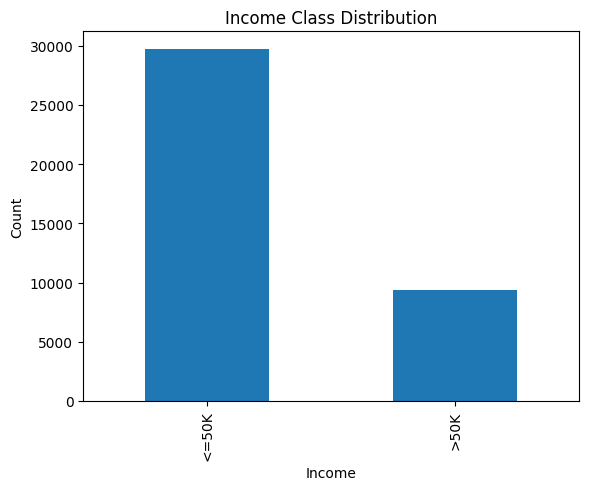

In [ ]:
import matplotlib.pyplot as plt

train_df['income'].value_counts().plot(kind='bar')

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

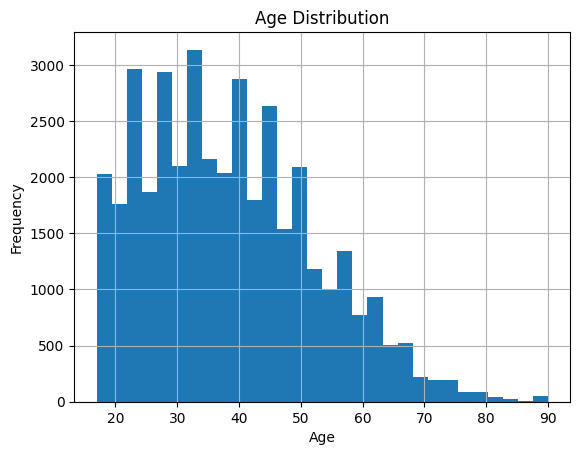

In [ ]:
train_df['age'].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

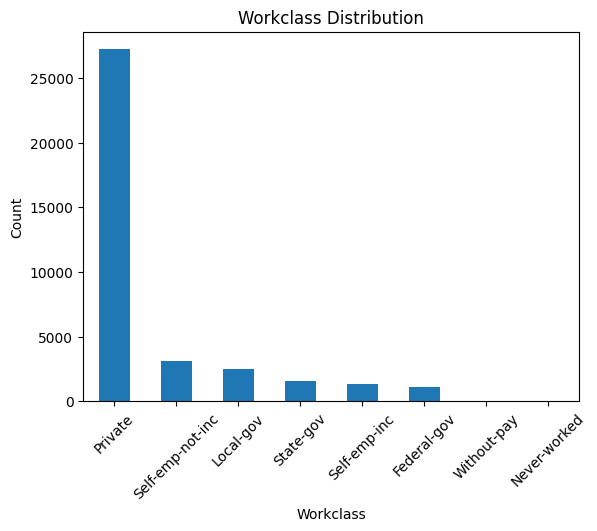

In [ ]:
train_df['workclass'].value_counts().plot(kind='bar')

plt.title("Workclass Distribution")
plt.xlabel("Workclass")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

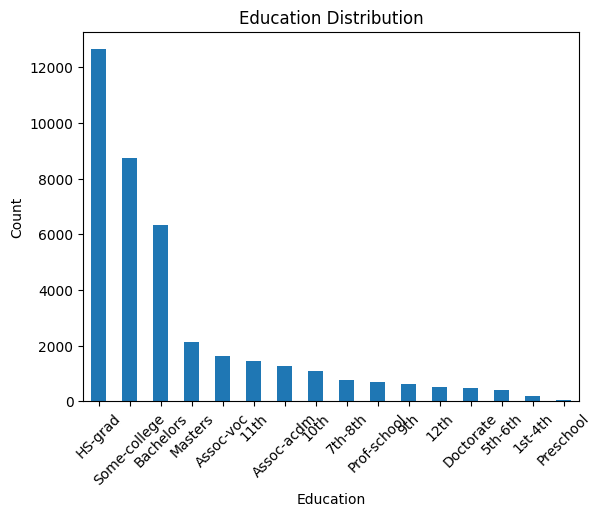

In [ ]:
train_df['education'].value_counts().plot(kind='bar')

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

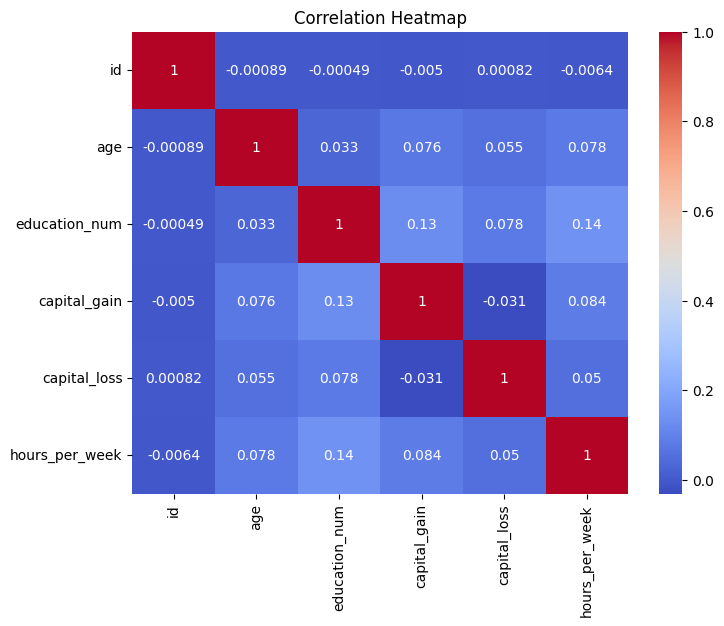

In [ ]:
import seaborn as sns

corr = train_df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
for col in train_df.columns:
    if train_df[col].dtype == "object":
        print(col, ":", (train_df[col] == "?").sum())

workclass : 0
education : 0
marital_status : 0
occupation : 0
relationship : 0
race : 0
sex : 0
native_country : 0
income : 0


In [ ]:
cat_cols = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

for col in cat_cols:
    mode_value = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_value)
    test_df[col] = test_df[col].fillna(mode_value)

print("[train missing after fill]")
print(train_df.isnull().sum())

print("\n[test missing after fill]")
print(test_df.isnull().sum())

[train missing after fill]
id                0
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

[test missing after fill]
id                0
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64


In [ ]:
y_train = train_df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print(y_train.value_counts())

income
0    29729
1     9344
Name: count, dtype: int64


In [ ]:
train_features = train_df.drop(columns=["income"])
test_features = test_df.copy()

full_df = pd.concat([train_features, test_features], axis=0)

full_encoded = pd.get_dummies(full_df, columns=cat_cols)

X_train = full_encoded.iloc[:len(train_df)]
X_test = full_encoded.iloc[len(train_df):]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (39073, 105)
X_test shape: (9769, 105)


In [ ]:
display(X_train.head())
display(y_train.head())

,id,age,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,37194,50,14,0,0,35,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,31094,28,10,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,33815,29,9,0,1902,35,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,14501,32,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,23400,62,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


,income
0,0
1,0
2,1
3,0
4,0


In [ ]:
test_id = test_df["id"]

X_train.to_csv("X_train_preprocessed.csv", index=False)
X_test.to_csv("X_test_preprocessed.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
test_id.to_csv("test_id.csv", index=False)

## Baseline Modeling
5/11 작업: Logistic Regression, Random Forest 베이스라인 학습 및 평가

In [ ]:
# id 컬럼 제거 (식별자라 학습에 사용되면 안 됨)
if 'id' in X_train.columns:
    X_train = X_train.drop(columns=['id'])
    X_test = X_test.drop(columns=['id'])
    print("id column dropped")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


id column dropped
X_train shape: (39073, 104)
X_test shape: (9769, 104)


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42

# stratified split (클래스 비율 유지하며 8:2 분할)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("train:", X_tr.shape, "  val:", X_val.shape)
print("\ntrain class ratio:")
print(y_tr.value_counts(normalize=True))


train: (31258, 104)   val: (7815, 104)

train class ratio:
income
0    0.760861
1    0.239139
Name: proportion, dtype: float64


In [ ]:
def evaluate(model, X_val, y_val, name="model"):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    score = (f1 + auc) / 2
    print(f"[{name}]  F1 = {f1:.4f}  AUC = {auc:.4f}  (F1+AUC)/2 = {score:.4f}")
    return {"name": name, "f1": f1, "auc": auc, "score": score}


### Baseline 1: Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_tr, y_tr)
lr_result = evaluate(lr, X_val, y_val, name="LogisticRegression")


[LogisticRegression]  F1 = 0.6587  AUC = 0.9063  (F1+AUC)/2 = 0.7825


### Baseline 2: Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_result = evaluate(rf, X_val, y_val, name="RandomForest")


[RandomForest]  F1 = 0.6599  AUC = 0.8929  (F1+AUC)/2 = 0.7764


### 5-fold Cross Validation
단일 split보다 안정적인 성능 평가.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv_f1 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
rf_cv_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"RF 5-fold CV F1 : {rf_cv_f1.mean():.4f}  (±{rf_cv_f1.std():.4f})")
print(f"RF 5-fold CV AUC: {rf_cv_auc.mean():.4f}  (±{rf_cv_auc.std():.4f})")
print(f"RF 5-fold CV (F1+AUC)/2: {(rf_cv_f1.mean() + rf_cv_auc.mean()) / 2:.4f}")


RF 5-fold CV F1 : 0.6552  (±0.0057)
RF 5-fold CV AUC: 0.8917  (±0.0033)
RF 5-fold CV (F1+AUC)/2: 0.7734


### Test set 예측 & prediction.csv 생성

In [ ]:
# 전체 train 데이터로 최종 모델 재학습
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_test_pred = rf_final.predict(X_test)
y_test_prob = rf_final.predict_proba(X_test)[:, 1]

prediction = pd.DataFrame({
    "id": test_id.values,
    "y_cls": y_test_pred,
    "y_prob": y_test_prob
})

prediction.to_csv("prediction.csv", index=False)

print(prediction.head())
print(f"\nprediction.csv saved, {len(prediction)} rows")


      id  y_cls    y_prob
0   7763      0  0.000000
1  23882      0  0.452972
2  30508      0  0.135000
3  28912      1  0.855000
4  19485      0  0.000000

prediction.csv saved, 9769 rows


### Feature Importance Top 15

In [ ]:
feat_imp = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features:")
print(feat_imp.head(15))


Top 15 features:
age                                  0.238986
hours_per_week                       0.119514
capital_gain                         0.107249
marital_status_Married-civ-spouse    0.074140
education_num                        0.067783
relationship_Husband                 0.044130
capital_loss                         0.036359
occupation_Exec-managerial           0.018330
marital_status_Never-married         0.016192
education_Bachelors                  0.011928
relationship_Not-in-family           0.011744
workclass_Private                    0.011220
relationship_Own-child               0.010629
occupation_Prof-specialty            0.010617
relationship_Wife                    0.010182
dtype: float64


In [31]:
### Baseline 3: LightGBM (종합 분석 버전)

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
import numpy as np

# [STEP 1] 단일 분할(Single Split) 성능 확인 ---

lgbm_single = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_single.fit(X_tr, y_tr)

lgbm_result = evaluate(lgbm_single, X_val, y_val, name="LightGBM (Single Split)")


# [STEP 2] 5-fold 교차 검증(CV)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1_scores = []
cv_auc_scores = []



for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):

    X_train_cv, y_train_cv = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val_cv, y_val_cv = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train_cv, y_train_cv)


    y_val_pred = model.predict(X_val_cv)
    y_val_prob = model.predict_proba(X_val_cv)[:, 1]

    cv_f1_scores.append(f1_score(y_val_cv, y_val_pred))
    cv_auc_scores.append(roc_auc_score(y_val_cv, y_val_prob))




mean_f1 = np.mean(cv_f1_scores)
mean_auc = np.mean(cv_auc_scores)

print("\n" + "="*40)
print(f"[LightGBM 5-fold CV 최종 결과]")
print(f"- 평균 F1 Score: {mean_f1:.4f}")
print(f"- 평균 AUC Score: {mean_auc:.4f}")
print(f"- 최종 평균: {(mean_f1 + mean_auc)/2:.4f}")
print("="*40)


# [STEP 3]prediction_lgbm.csv 생성
lgbm_final = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_final.fit(X_train, y_train)


y_test_pred_lgbm = lgbm_final.predict(X_test)
y_test_prob_lgbm = lgbm_final.predict_proba(X_test)[:, 1]


prediction_lgbm = pd.DataFrame({
    "id": test_id.values,
    "y_cls": y_test_pred_lgbm,
    "y_prob": y_test_prob_lgbm
})

prediction_lgbm.to_csv("prediction_lgbm.csv", index=False)


[LightGBM (Single Split)]  F1 = 0.7188  AUC = 0.9288  (F1+AUC)/2 = 0.8238

[LightGBM 5-fold CV 최종 결과]
- 평균 F1 Score: 0.7104
- 평균 AUC Score: 0.9280
- 최종 평균: 0.8192
